In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HIST_COLOR = '#2C497F'   # Historical
FUT_COLOR  = '#B24C4C'   # Future

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2
plt.style.use('seaborn-whitegrid')

def synthetic_rainfall(hours, dt_min, peak_mm_h=25.0, width_h=2.0, skew=0.5, peak_time_frac=0.45):
    n = int(hours * 60.0 / dt_min)
    t = np.linspace(0, hours, n)
    t0 = hours * peak_time_frac
    sigma_left  = max(0.2, width_h * (1.0 - 0.5*skew))
    sigma_right = max(0.2, width_h * (1.0 + 0.5*skew))
    sigma = np.where(t <= t0, sigma_left, sigma_right)
    r = np.exp(-0.5 * ((t - t0) / (sigma + 1e-9))**2)
    r /= r.max() + 1e-12
    r *= peak_mm_h
    return t, r

def gamma_unit_hydrograph(t, k=1.8, theta=0.6):
    x = t / (theta + 1e-12)
    uh = (x**(k-1)) * np.exp(-x)
    uh[0] = 0.0
    uh /= uh.max() + 1e-12
    return uh

def runoff_from_rain(t, rain_mm_h, dt_min, uh_k=1.9, uh_theta=0.7):
    dt_h = dt_min / 60.0
    uh_t = np.arange(0, 6.0, dt_h)
    uh = gamma_unit_hydrograph(uh_t, k=uh_k, theta=uh_theta)
    eff = rain_mm_h * dt_h
    q = np.convolve(eff, uh, mode='full')[:len(eff)]
    return q / (dt_h + 1e-12)

def normalize_peak(series, desired_peak):
    smax = series.max() if series.max() > 0 else 1.0
    return series * (desired_peak / smax)

def make_panel(ax1, ax2, duration_h, dt_min,
               hist_peak_cms, fut_peak_cms,
               hist_rain_peak=16, hist_width_h=3.2, hist_skew=0.35, hist_peak_time=0.50,
               fut_rain_peak=34,  fut_width_h=1.1,  fut_skew=0.65,  fut_peak_time=0.45,
               uh_k=1.9, uh_theta=0.7):

    t, r_hist = synthetic_rainfall(duration_h, dt_min,
                                   peak_mm_h=hist_rain_peak,
                                   width_h=hist_width_h,
                                   skew=hist_skew,
                                   peak_time_frac=hist_peak_time)
    _, r_fut = synthetic_rainfall(duration_h, dt_min,
                                  peak_mm_h=fut_rain_peak,
                                  width_h=fut_width_h,
                                  skew=fut_skew,
                                  peak_time_frac=fut_peak_time)

    q_hist = normalize_peak(runoff_from_rain(t, r_hist, dt_min, uh_k=uh_k, uh_theta=uh_theta), hist_peak_cms)
    q_fut  = normalize_peak(runoff_from_rain(t, r_fut,  dt_min, uh_k=uh_k, uh_theta=uh_theta),  fut_peak_cms)

    # Discharge
    ax1.plot(t, q_hist, color=HIST_COLOR, linewidth=2.6, label='Historical')
    ax1.plot(t, q_fut,  color=FUT_COLOR,  linewidth=2.6, label='Future')

    # Rainfall
    ax2.bar(t, r_hist, width=0.1, color=HIST_COLOR, alpha=0.25)
    ax2.bar(t, r_fut,  width=0.1, color=FUT_COLOR,  alpha=0.25)

    # Axes (centered layout like reference figure)
    ax1.set_xlabel('Time [hours]', fontsize=22)
    ax1.set_ylabel('Discharge [m$^3$ s$^{-1}$]', fontsize=22)
    ax2.set_ylabel('Rainfall [mm h$^{-1}$]', fontsize=22)

    ax1.yaxis.set_label_coords(-0.05, 0.3)
    ax2.yaxis.set_label_coords(1.07, 0.7)

    ax1.set_ylim(0, 160)
    ax2.set_ylim(240, 0)

    ax1.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
    ax2.set_yticks([0, 20, 40, 60, 80, 100, 120])

    ax1.set_xticks(np.arange(0, duration_h + 3, 3))
    ax1.set_xlim(0, duration_h)

    # Format frame and grid
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', labelsize=24, width=2)
        ax.grid(True)

    ax1.legend(loc='upper right', fontsize=24, frameon=True)

def plot_dual_hydrographs(duration_hours=36, dt_minutes=5):
    plt.figure(figsize=(12, 10))

    # Weak peaks: 20 → 10
    ax1 = plt.subplot(2, 1, 1)
    ax2 = ax1.twinx()
    make_panel(ax1, ax2, duration_hours, dt_minutes,
               hist_peak_cms=20, fut_peak_cms=10,
               hist_rain_peak=16, hist_width_h=3.4, hist_skew=0.35, hist_peak_time=0.52,
               fut_rain_peak=34,  fut_width_h=1.0,  fut_skew=0.70,  fut_peak_time=0.46,
               uh_k=1.9, uh_theta=0.70)

    # Strong peaks: 50 → 70
    ax3 = plt.subplot(2, 1, 2, sharex=ax1)
    ax4 = ax3.twinx()
    make_panel(ax3, ax4, duration_hours, dt_minutes,
               hist_peak_cms=50, fut_peak_cms=70,
               hist_rain_peak=22, hist_width_h=3.0, hist_skew=0.35, hist_peak_time=0.52,
               fut_rain_peak=40, fut_width_h=1.2,  fut_skew=0.70, fut_peak_time=0.46,
               uh_k=1.9, uh_theta=0.70)

    plt.tight_layout()
    plt.show()

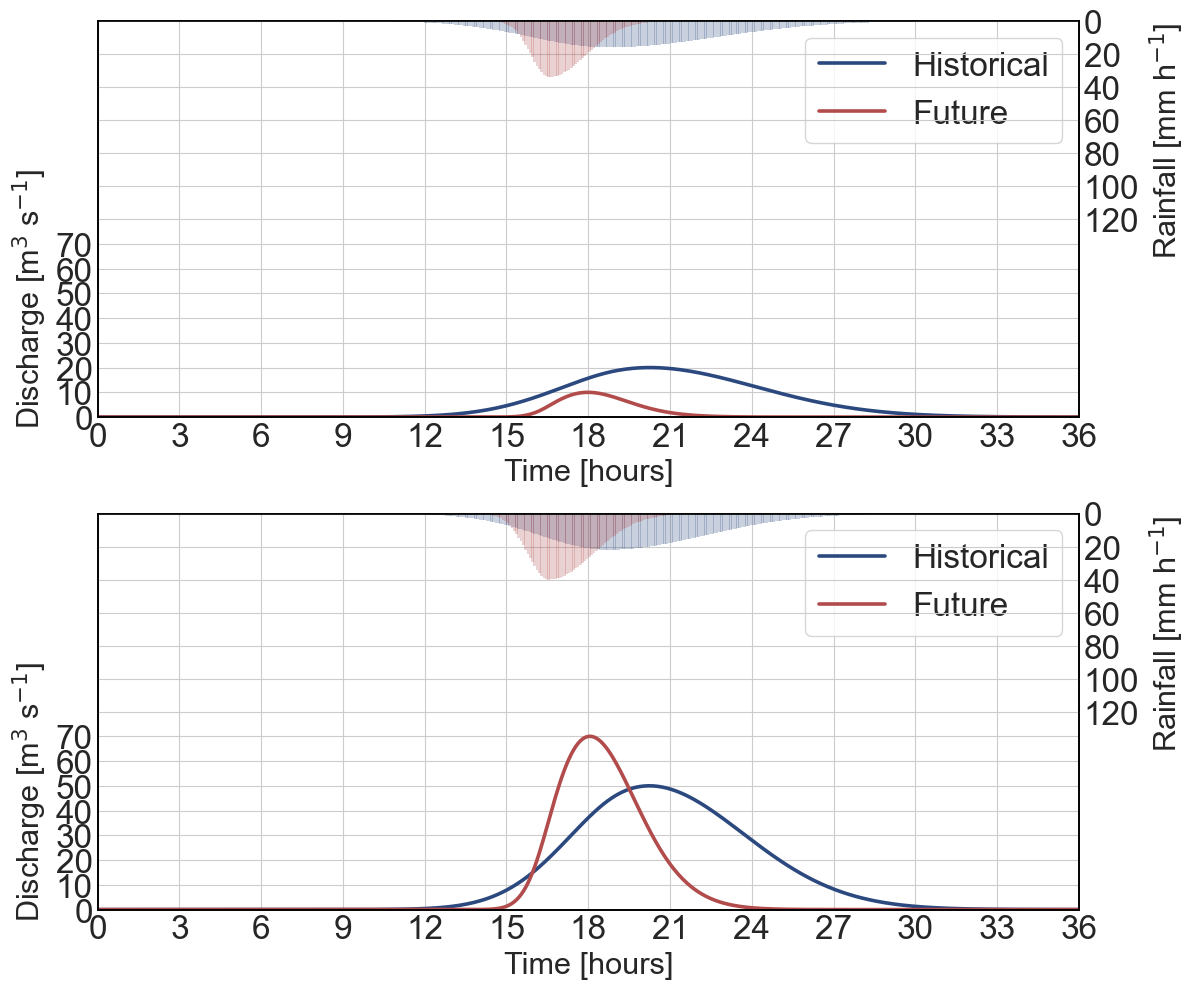

In [2]:
# --- Run ---
plot_dual_hydrographs()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HIST_COLOR = '#2C497F'   # Historical
FUT_COLOR  = '#B24C4C'   # Future

plt.style.use('seaborn-whitegrid')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2

# ===== Rain generator (PURE NORMAL, symmetric) =====
def synthetic_rainfall(hours, dt_min, peak_mm_h=25.0, width_h=2.0, peak_time_frac=0.45):
    """Symmetric Gaussian hyetograph (mm/h)."""
    n = int(hours * 60.0 / dt_min)
    t = np.linspace(0, hours, n)
    t0 = hours * peak_time_frac
    sigma = max(0.2, float(width_h))
    r = np.exp(-0.5 * ((t - t0) / (sigma + 1e-9))**2)
    r /= r.max() + 1e-12
    r *= peak_mm_h
    return t, r

# ===== Unit hydrograph for discharge (lognormal with fat tail) =====
def lognormal_unit_hydrograph(t, t_mode=1.0, sigma=0.95):
    t = np.asarray(t, dtype=float)
    t_eps = np.maximum(t, 1e-6)
    mu = np.log(t_mode) + sigma**2
    pdf = (1.0 / (t_eps * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(t_eps) - mu)**2 / (2*sigma**2))
    pdf[0] = 0.0
    pdf /= pdf.max() + 1e-12
    return pdf

def runoff_from_rain(t, rain_mm_h, dt_min, uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0):
    """
    Convolve rainfall with lognormal UH and delay discharge peak by runoff_delay_h hours.
    """
    dt_h = dt_min / 60.0
    uh_t = np.arange(0, 10.0, dt_h)
    uh = lognormal_unit_hydrograph(uh_t, t_mode=uh_tmode, sigma=uh_sigma)
    eff = rain_mm_h * dt_h
    q = np.convolve(eff, uh, mode='full')[:len(eff)]
    q /= (dt_h + 1e-12)
    # shift runoff in time to increase lagtime
    shift_steps = int(runoff_delay_h / dt_h)
    q = np.roll(q, shift_steps)
    q[:shift_steps] = 0.0
    return q

def normalize_peak(series, desired_peak):
    smax = series.max() if series.max() > 0 else 1.0
    return series * (desired_peak / smax)

# ===== Utilities =====
def plot_fill_rain(ax2, t, rain, color, alpha_fill=0.16, lw=1.2, gutter=0.33):
    rain_vis = rain * (1.0 - gutter)
    ax2.fill_between(t, 0, rain_vis, alpha=alpha_fill, color=color, linewidth=0, zorder=1)
    ax2.plot(t, rain_vis, color=color, linewidth=lw, alpha=0.75, zorder=1.1)

def make_panel(ax1, ax2, duration_h, dt_min,
               hist_peak_cms, fut_peak_cms,
               hist_rain_peak, hist_width_h, hist_peak_time,
               fut_rain_peak,  fut_width_h,  fut_peak_time,
               uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0,
               q_ylim=(0, 100), r_ylim=(120, 0),
               t_target_frac=0.55):

    # --- Rain (symmetric) ---
    t, r_hist = synthetic_rainfall(duration_h, dt_min, hist_rain_peak, hist_width_h, hist_peak_time)
    _, r_fut  = synthetic_rainfall(duration_h, dt_min, fut_rain_peak,  fut_width_h,  fut_peak_time)

    # --- Discharge (delayed UH) ---
    q_hist = normalize_peak(runoff_from_rain(t, r_hist, dt_min, uh_tmode, uh_sigma, runoff_delay_h), hist_peak_cms)
    q_fut  = normalize_peak(runoff_from_rain(t, r_fut,  dt_min, uh_tmode, uh_sigma, runoff_delay_h),  fut_peak_cms)

    # Align both to same visual target
    t_target = duration_h * t_target_frac
    th = t[np.argmax(q_hist)]; tf = t[np.argmax(q_fut)]
    dt_hist = t_target - th;   dt_fut = t_target - tf

    # Draw
    ax1.set_zorder(2); ax2.set_zorder(0); ax1.patch.set_alpha(0.0)
    plot_fill_rain(ax2, t + dt_hist, r_hist, HIST_COLOR)
    plot_fill_rain(ax2, t + dt_fut,  r_fut,  FUT_COLOR)
    ax1.plot(t + dt_hist, q_hist, color=HIST_COLOR, linewidth=2.8, label='Historical', zorder=3)
    ax1.plot(t + dt_fut,  q_fut,  color=FUT_COLOR,  linewidth=2.8, label='Future',     zorder=3)

    ax1.set_xticks([]); ax1.set_yticks([]); ax2.set_yticks([])
    ax1.set_xlabel('Time', fontsize=30, labelpad=6)
    ax1.set_ylabel('Discharge', fontsize=30, labelpad=2)
    ax2.set_ylabel('Rainfall',     fontsize=30, labelpad=2)
    ax1.yaxis.set_label_coords(-0.015, 0.20)
    ax2.yaxis.set_label_coords(1.015, 0.8)

    ax1.set_xlim(0, duration_h)
    ax1.set_ylim(*q_ylim)
    ax2.set_ylim(*r_ylim)

    for spine in ax1.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(1.0)
    for spine in ax2.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(1.0)
    ax1.grid(False); ax2.grid(False)
#     ax1.legend(loc='upper right', fontsize=18, frameon=False)

# ===== Figure =====
def plot_dual_hydrographs(duration_hours=36, dt_minutes=5):
    # ---------- Figure 1: Weak gets weaker ----------
    plt.figure(figsize=(8, 8))
    ax1 = plt.subplot(1, 1, 1)
    ax2 = ax1.twinx()
    make_panel(ax1, ax2, duration_hours, dt_minutes,
               hist_peak_cms=15, fut_peak_cms=5,
               hist_rain_peak=6, hist_width_h=3.4, hist_peak_time=0.52,
               fut_rain_peak=3,  fut_width_h=1.0,  fut_peak_time=0.46,
               runoff_delay_h=1.0,
               q_ylim=(0, 100), r_ylim=(120, 0),
               t_target_frac=0.55)
#     plt.title("Weak peaks weaken", fontsize=20, pad=15)
    plt.tight_layout()
    plt.show()

    # ---------- Figure 2: Strong gets stronger ----------
    plt.figure(figsize=(8, 8))
    ax3 = plt.subplot(1, 1, 1)
    ax4 = ax3.twinx()
    make_panel(ax3, ax4, duration_hours, dt_minutes,
               hist_peak_cms=30, fut_peak_cms=38,
               hist_rain_peak=22, hist_width_h=3.0, hist_peak_time=0.52,
               fut_rain_peak=40, fut_width_h=1.2,  fut_peak_time=0.46,
               runoff_delay_h=1.0,
               q_ylim=(0, 100), r_ylim=(120, 0),
               t_target_frac=0.55)
#     plt.title("Strong peaks strengthen", fontsize=20, pad=15)
    plt.tight_layout()
    plt.show()


# --- Run ---
# plot_dual_hydrographs()


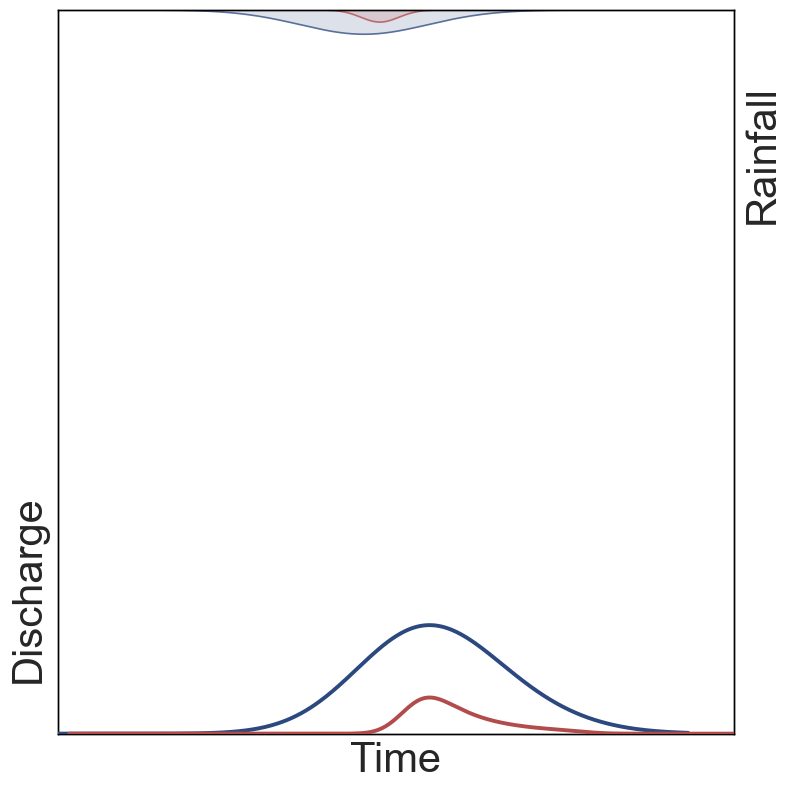

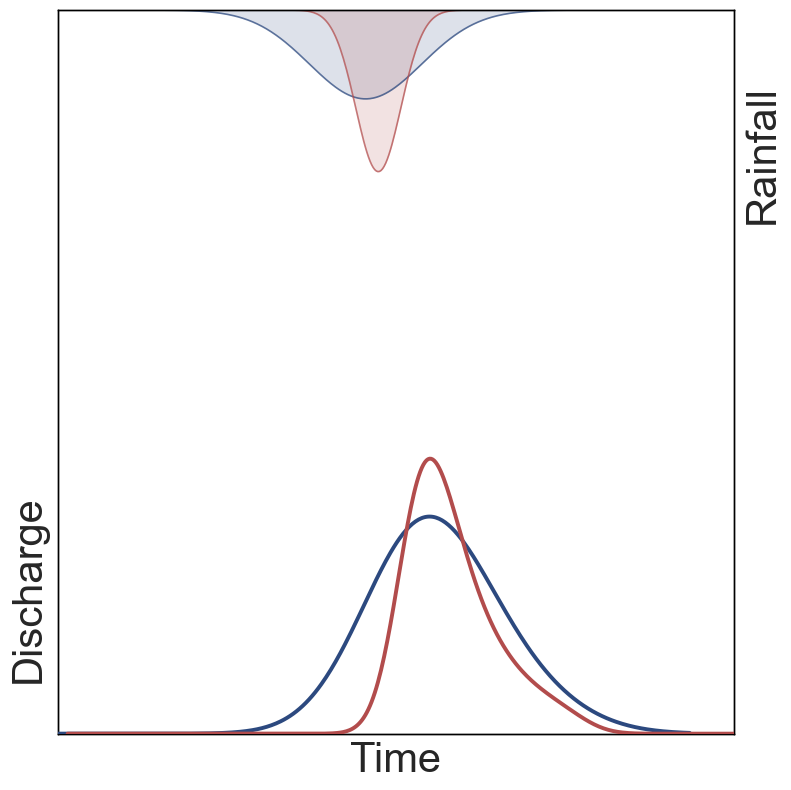

In [4]:

plot_dual_hydrographs()

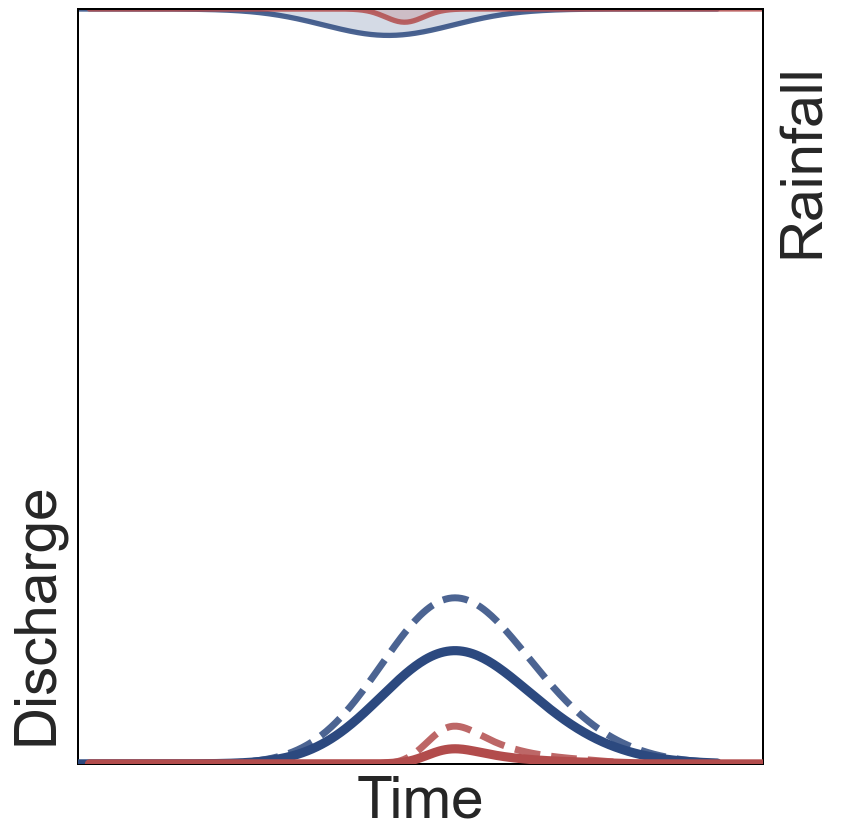

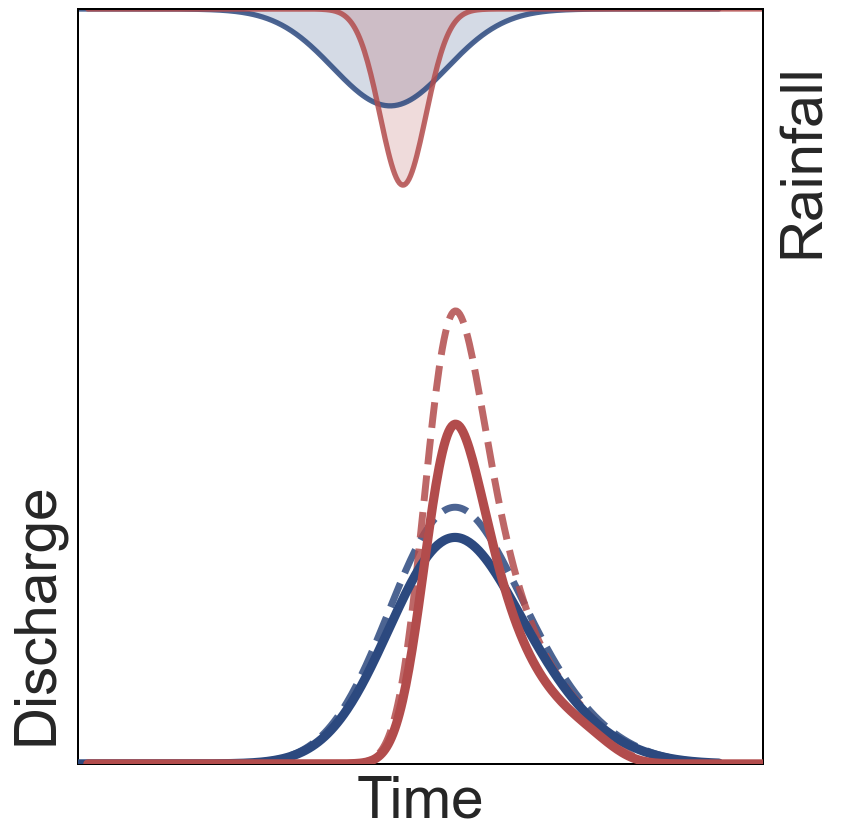

In [12]:
import numpy as np
import matplotlib.pyplot as plt

HIST_COLOR = '#2C497F'   # Historical
FUT_COLOR  = '#B24C4C'   # Future

# =========================
# Global style (bigger text, thicker lines)
# =========================
plt.style.use('seaborn-whitegrid')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.6

plt.rcParams['axes.labelsize'] = 38
plt.rcParams['xtick.labelsize'] = 28
plt.rcParams['ytick.labelsize'] = 28

plt.rcParams['legend.fontsize'] = 24
plt.rcParams['lines.linewidth'] = 4.0


# =========================
# Rain generator (PURE NORMAL, symmetric)
# =========================
def synthetic_rainfall(hours, dt_min, peak_mm_h=25.0, width_h=2.0, peak_time_frac=0.45):
    """Symmetric Gaussian hyetograph (mm/h)."""
    n = int(hours * 60.0 / dt_min)
    t = np.linspace(0, hours, n)
    t0 = hours * peak_time_frac
    sigma = max(0.2, float(width_h))
    r = np.exp(-0.5 * ((t - t0) / (sigma + 1e-9))**2)
    r /= r.max() + 1e-12
    r *= peak_mm_h
    return t, r


# =========================
# Unit hydrograph for discharge (lognormal with fat tail)
# =========================
def lognormal_unit_hydrograph(t, t_mode=1.0, sigma=0.95):
    t = np.asarray(t, dtype=float)
    t_eps = np.maximum(t, 1e-6)
    mu = np.log(t_mode) + sigma**2
    pdf = (1.0 / (t_eps * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(t_eps) - mu)**2 / (2*sigma**2))
    pdf[0] = 0.0
    pdf /= pdf.max() + 1e-12
    return pdf


def runoff_from_rain(t, rain_mm_h, dt_min, uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0):
    """
    Convolve rainfall with lognormal UH and delay discharge peak by runoff_delay_h hours.
    """
    dt_h = dt_min / 60.0
    uh_t = np.arange(0, 10.0, dt_h)
    uh = lognormal_unit_hydrograph(uh_t, t_mode=uh_tmode, sigma=uh_sigma)

    eff = rain_mm_h * dt_h
    q = np.convolve(eff, uh, mode='full')[:len(eff)]
    q /= (dt_h + 1e-12)

    shift_steps = int(runoff_delay_h / dt_h)
    q = np.roll(q, shift_steps)
    q[:shift_steps] = 0.0
    return q


def normalize_peak(series, desired_peak):
    smax = series.max() if series.max() > 0 else 1.0
    return series * (desired_peak / smax)


# =========================
# Plot helpers
# =========================
def plot_fill_rain(ax2, t, rain, color, alpha_fill=0.20, lw=3.2, gutter=0.30):
    rain_vis = rain * (1.0 - gutter)
    ax2.fill_between(t, 0, rain_vis, alpha=alpha_fill, color=color, linewidth=0, zorder=1)
    ax2.plot(t, rain_vis, color=color, linewidth=lw, alpha=0.85, zorder=1.1)


def make_panel(ax1, ax2, duration_h, dt_min,
               hist_peak_cms, fut_peak_cms,
               hist_rain_peak, hist_width_h, hist_peak_time,
               fut_rain_peak,  fut_width_h,  fut_peak_time,
               uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0,
               q_ylim=(0, 100), r_ylim=(120, 0),
               t_target_frac=0.55,
               q_lw=6.0, rain_lw=3.2,
               dashed_hist_peak=None,
               dashed_fut_peak=None,
               dashed_lw=4.0,
               dashed_ls='--',
               label_fs=40):

    # --- Rain ---
    t, r_hist = synthetic_rainfall(duration_h, dt_min, hist_rain_peak, hist_width_h, hist_peak_time)
    _, r_fut  = synthetic_rainfall(duration_h, dt_min, fut_rain_peak,  fut_width_h,  fut_peak_time)

    # --- Discharge (solid) ---
    q_hist = normalize_peak(runoff_from_rain(t, r_hist, dt_min, uh_tmode, uh_sigma, runoff_delay_h), hist_peak_cms)
    q_fut  = normalize_peak(runoff_from_rain(t, r_fut,  dt_min, uh_tmode, uh_sigma, runoff_delay_h),  fut_peak_cms)

    # --- Optional dashed hydrographs ---
    q_hist_dashed = None
    q_fut_dashed = None

    if dashed_hist_peak is not None:
        q_hist_dashed = normalize_peak(
            runoff_from_rain(t, r_hist, dt_min, uh_tmode, uh_sigma, runoff_delay_h),
            dashed_hist_peak
        )

    if dashed_fut_peak is not None:
        q_fut_dashed = normalize_peak(
            runoff_from_rain(t, r_fut, dt_min, uh_tmode, uh_sigma, runoff_delay_h),
            dashed_fut_peak
        )

    # Align both to same visual target (use solid peaks as reference)
    t_target = duration_h * t_target_frac
    th = t[np.argmax(q_hist)]
    tf = t[np.argmax(q_fut)]
    dt_hist = t_target - th
    dt_fut  = t_target - tf

    # Draw
    ax1.set_zorder(2)
    ax2.set_zorder(0)
    ax1.patch.set_alpha(0.0)

    plot_fill_rain(ax2, t + dt_hist, r_hist, HIST_COLOR, lw=rain_lw)
    plot_fill_rain(ax2, t + dt_fut,  r_fut,  FUT_COLOR,  lw=rain_lw)

    # Solid lines
    ax1.plot(t + dt_hist, q_hist, color=HIST_COLOR, linewidth=q_lw, zorder=3, label='Historical')
    ax1.plot(t + dt_fut,  q_fut,  color=FUT_COLOR,  linewidth=q_lw, zorder=3, label='Future')

    # Dashed lines
    if q_hist_dashed is not None:
        ax1.plot(t + dt_hist, q_hist_dashed,
                 color=HIST_COLOR,
                 linewidth=dashed_lw,
                 linestyle=dashed_ls,
                 alpha=0.85,
                 zorder=2.6)

    if q_fut_dashed is not None:
        ax1.plot(t + dt_fut, q_fut_dashed,
                 color=FUT_COLOR,
                 linewidth=dashed_lw,
                 linestyle=dashed_ls,
                 alpha=0.85,
                 zorder=2.6)

    # Labels / axes
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_yticks([])

    ax1.set_xlabel('Time', fontsize=label_fs, labelpad=8)
    ax1.set_ylabel('Discharge', fontsize=label_fs, labelpad=4)
    ax2.set_ylabel('Rainfall', fontsize=label_fs, labelpad=4)

    ax1.yaxis.set_label_coords(-0.02, 0.20)
    ax2.yaxis.set_label_coords(1.02, 0.80)

    ax1.set_xlim(0, duration_h)
    ax1.set_ylim(*q_ylim)
    ax2.set_ylim(*r_ylim)

    # Spines
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.4)
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.4)

    ax1.grid(False)
    ax2.grid(False)
    # ax1.legend(loc='upper right', frameon=False)


# =========================
# Figure
# =========================
def plot_dual_hydrographs(duration_hours=36, dt_minutes=5):
    # -------- Figure 1: Weak gets weaker --------
    plt.figure(figsize=(8.5, 8.5))
    ax1 = plt.subplot(1, 1, 1)
    ax2 = ax1.twinx()
    make_panel(
        ax1, ax2, duration_hours, dt_minutes,
        hist_peak_cms=15, fut_peak_cms=2,
        hist_rain_peak=6,  hist_width_h=3.4, hist_peak_time=0.52,
        fut_rain_peak=3,   fut_width_h=1.0,  fut_peak_time=0.46,
        runoff_delay_h=1.0,
        dashed_hist_peak=22,   # dashed blue peak
        dashed_fut_peak=5,    # dashed red peak
        q_ylim=(0, 100), r_ylim=(120, 0),
        t_target_frac=0.55,
        q_lw=6.6, rain_lw=3.8,
        dashed_lw=5.0,
        dashed_ls='--',
        label_fs=42
    )
    plt.tight_layout()
    plt.show()

    # -------- Figure 2: Strong gets stronger --------
    plt.figure(figsize=(8.5, 8.5))
    ax3 = plt.subplot(1, 1, 1)
    ax4 = ax3.twinx()
    make_panel(
        ax3, ax4, duration_hours, dt_minutes,
        hist_peak_cms=30, fut_peak_cms=45,
        hist_rain_peak=22, hist_width_h=3.0, hist_peak_time=0.52,
        fut_rain_peak=40,  fut_width_h=1.2,  fut_peak_time=0.46,
        runoff_delay_h=1.0,
        dashed_hist_peak=34,
        dashed_fut_peak=60,
        q_ylim=(0, 100), r_ylim=(120, 0),
        t_target_frac=0.55,
        q_lw=6.6, rain_lw=3.8,
        dashed_lw=5.0,
        dashed_ls='--',
        label_fs=42
    )
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_dual_hydrographs()


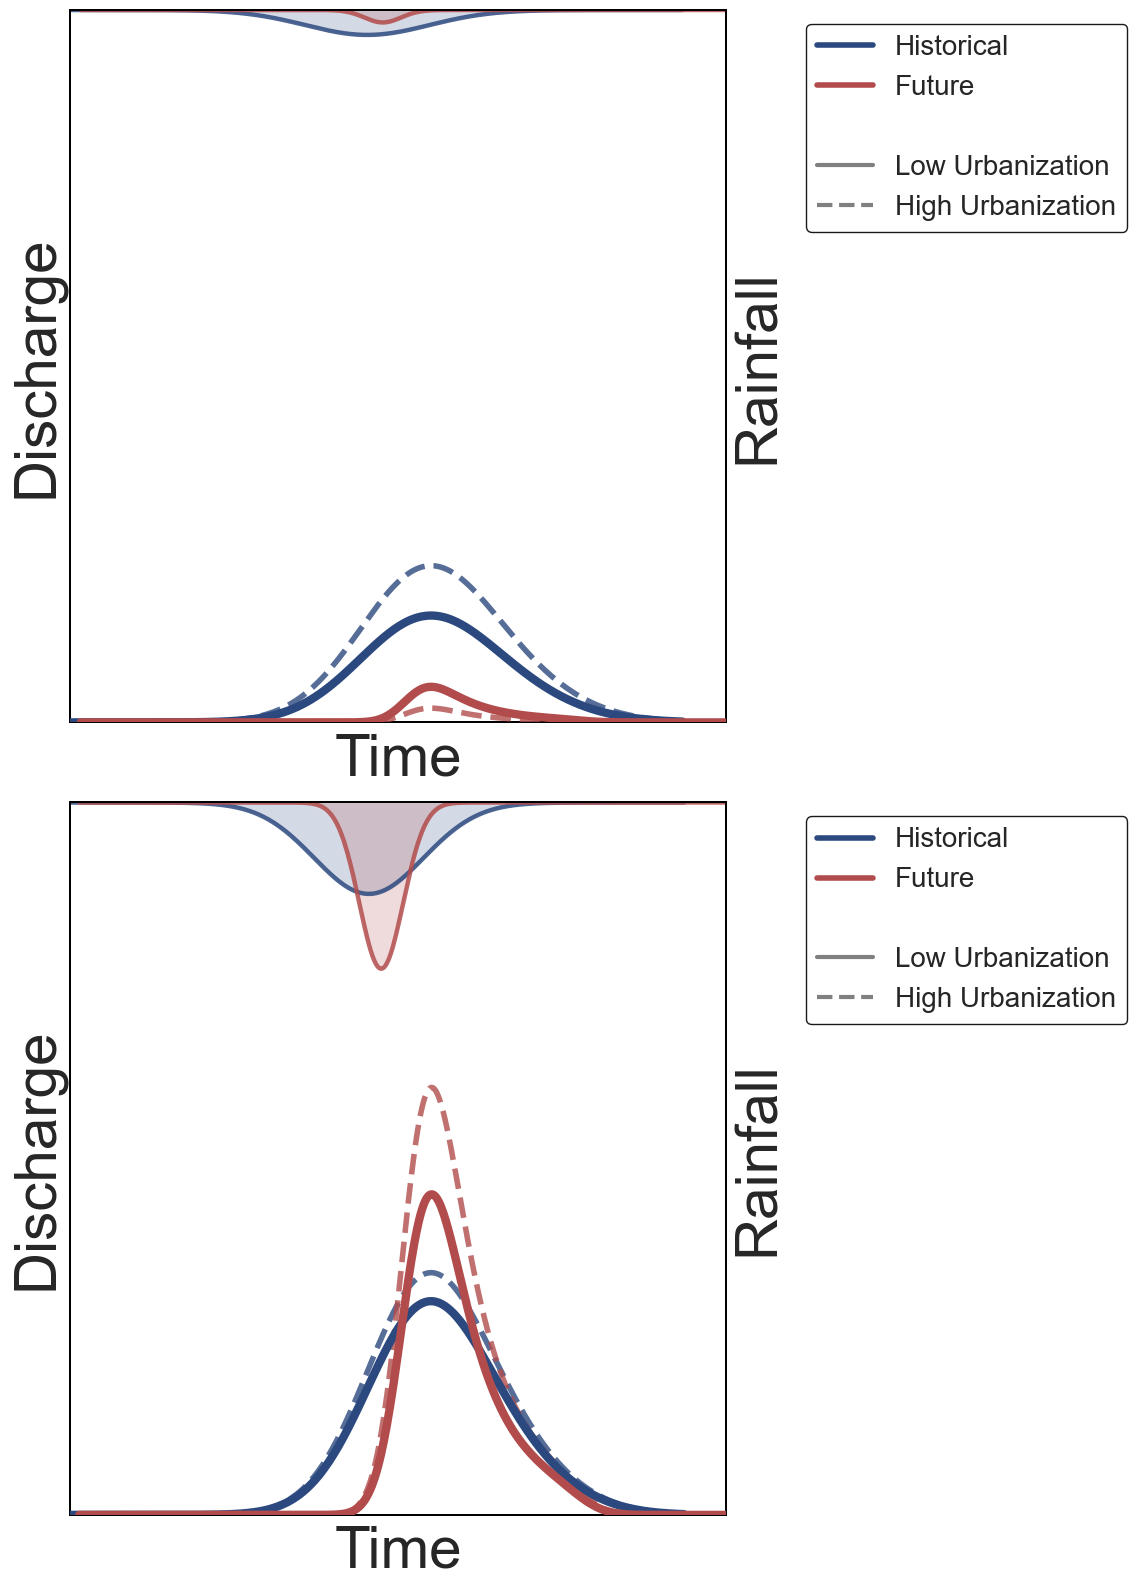

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

HIST_COLOR = '#2C497F'   # Historical
FUT_COLOR  = '#B24C4C'   # Future

# =========================
# Global style (bigger text, thicker lines)
# =========================
try:
    plt.style.use('seaborn-whitegrid')
except:
    plt.style.use('ggplot')

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.6
plt.rcParams['axes.labelsize'] = 38
plt.rcParams['xtick.labelsize'] = 28
plt.rcParams['ytick.labelsize'] = 28
plt.rcParams['legend.fontsize'] = 24
plt.rcParams['lines.linewidth'] = 4.0

# =========================
# Rain generator
# =========================
def synthetic_rainfall(hours, dt_min, peak_mm_h=25.0, width_h=2.0, peak_time_frac=0.45):
    """Symmetric Gaussian hyetograph (mm/h)."""
    n = int(hours * 60.0 / dt_min)
    t = np.linspace(0, hours, n)
    t0 = hours * peak_time_frac
    sigma = max(0.2, float(width_h))
    r = np.exp(-0.5 * ((t - t0) / (sigma + 1e-9))**2)
    r /= r.max() + 1e-12
    r *= peak_mm_h
    return t, r

# =========================
# Unit hydrograph for discharge
# =========================
def lognormal_unit_hydrograph(t, t_mode=1.0, sigma=0.95):
    t = np.asarray(t, dtype=float)
    t_eps = np.maximum(t, 1e-6)
    mu = np.log(t_mode) + sigma**2
    pdf = (1.0 / (t_eps * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(t_eps) - mu)**2 / (2*sigma**2))
    pdf[0] = 0.0
    pdf /= pdf.max() + 1e-12
    return pdf

def runoff_from_rain(t, rain_mm_h, dt_min, uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0):
    """Convolve rainfall with lognormal UH and delay discharge peak."""
    dt_h = dt_min / 60.0
    uh_t = np.arange(0, 10.0, dt_h)
    uh = lognormal_unit_hydrograph(uh_t, t_mode=uh_tmode, sigma=uh_sigma)
    eff = rain_mm_h * dt_h
    q = np.convolve(eff, uh, mode='full')[:len(eff)]
    q /= (dt_h + 1e-12)
    shift_steps = int(runoff_delay_h / dt_h)
    q = np.roll(q, shift_steps)
    q[:shift_steps] = 0.0
    return q

def normalize_peak(series, desired_peak):
    smax = series.max() if series.max() > 0 else 1.0
    return series * (desired_peak / smax)

# =========================
# Plot helpers
# =========================
def plot_fill_rain(ax2, t, rain, color, alpha_fill=0.20, lw=3.2, gutter=0.30):
    rain_vis = rain * (1.0 - gutter)
    ax2.fill_between(t, 0, rain_vis, alpha=alpha_fill, color=color, linewidth=0, zorder=1)
    ax2.plot(t, rain_vis, color=color, linewidth=lw, alpha=0.85, zorder=1.1)

def add_custom_legend(ax):
    """Creates a unified legend outside the plot area."""
    legend_elements = [
        Line2D([0], [0], color=HIST_COLOR, lw=4, label='Historical'),
        Line2D([0], [0], color=FUT_COLOR, lw=4, label='Future'),
        Line2D([0], [0], color='none', label=''), # Spacer
        Line2D([0], [0], color='gray', lw=3, linestyle='-', label='Low Urbanization'),
        Line2D([0], [0], color='gray', lw=3, linestyle='--', label='High Urbanization')
    ]
    # bbox_to_anchor places the legend relative to the axis (1.1 means 10% outside to the right)
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.1, 1),
              frameon=True, facecolor='white', framealpha=0.9, fontsize=20, edgecolor='black')

def make_panel(ax1, ax2, duration_h, dt_min,
                hist_peak_cms, fut_peak_cms,
                hist_rain_peak, hist_width_h, hist_peak_time,
                fut_rain_peak,  fut_width_h,  fut_peak_time,
                uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0,
                q_ylim=(0, 100), r_ylim=(120, 0),
                t_target_frac=0.55,
                q_lw=6.0, rain_lw=3.2,
                dashed_hist_peak=None,
                dashed_fut_peak=None,
                dashed_lw=4.0,
                dashed_ls='--',
                label_fs=42):

    # --- Calculations ---
    t, r_hist = synthetic_rainfall(duration_h, dt_min, hist_rain_peak, hist_width_h, hist_peak_time)
    _, r_fut  = synthetic_rainfall(duration_h, dt_min, fut_rain_peak,  fut_width_h,  fut_peak_time)

    q_hist = normalize_peak(runoff_from_rain(t, r_hist, dt_min, uh_tmode, uh_sigma, runoff_delay_h), hist_peak_cms)
    q_fut  = normalize_peak(runoff_from_rain(t, r_fut,  dt_min, uh_tmode, uh_sigma, runoff_delay_h),  fut_peak_cms)

    q_hist_dashed = normalize_peak(runoff_from_rain(t, r_hist, dt_min, uh_tmode, uh_sigma, runoff_delay_h), dashed_hist_peak) if dashed_hist_peak else None
    q_fut_dashed = normalize_peak(runoff_from_rain(t, r_fut, dt_min, uh_tmode, uh_sigma, runoff_delay_h), dashed_fut_peak) if dashed_fut_peak else None

    # Align peaks
    t_target = duration_h * t_target_frac
    th = t[np.argmax(q_hist)]; tf = t[np.argmax(q_fut)]
    dt_hist = t_target - th; dt_fut  = t_target - tf

    ax1.set_zorder(2); ax2.set_zorder(0); ax1.patch.set_alpha(0.0)

    # Plot
    plot_fill_rain(ax2, t + dt_hist, r_hist, HIST_COLOR, lw=rain_lw)
    plot_fill_rain(ax2, t + dt_fut,  r_fut,  FUT_COLOR,  lw=rain_lw)

    ax1.plot(t + dt_hist, q_hist, color=HIST_COLOR, linewidth=q_lw, zorder=3)
    ax1.plot(t + dt_fut,  q_fut,  color=FUT_COLOR,  linewidth=q_lw, zorder=3)

    if q_hist_dashed is not None:
        ax1.plot(t + dt_hist, q_hist_dashed, color=HIST_COLOR, linewidth=dashed_lw, linestyle=dashed_ls, alpha=0.8, zorder=2.6)
    if q_fut_dashed is not None:
        ax1.plot(t + dt_fut, q_fut_dashed, color=FUT_COLOR, linewidth=dashed_lw, linestyle=dashed_ls, alpha=0.8, zorder=2.6)

    # Styling
    ax1.set_xticks([]); ax1.set_yticks([]); ax2.set_yticks([])
    ax1.set_xlabel('Time', fontsize=label_fs, labelpad=8)
    ax1.set_ylabel('Discharge', fontsize=label_fs, labelpad=4)
    ax2.set_ylabel('Rainfall', fontsize=label_fs, labelpad=4)
    ax1.set_xlim(0, duration_h)
    ax1.set_ylim(*q_ylim); ax2.set_ylim(*r_ylim)
    
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.4)
        ax.grid(False)

    # Add Legend Outside
    add_custom_legend(ax1)

# =========================
# Figure execution
# =========================
def plot_dual_hydrographs(duration_hours=36, dt_minutes=5):
    # Use a wider figure to accommodate the legend on the right
    fig, axes = plt.subplots(2, 1, figsize=(14, 16))
    
    # Figure 1
    ax1 = axes[0]
    ax2 = ax1.twinx()
    make_panel(ax1, ax2, duration_hours, dt_minutes, hist_peak_cms=15, fut_peak_cms=5,
               hist_rain_peak=6, hist_width_h=3.4, hist_peak_time=0.52,
               fut_rain_peak=3, fut_width_h=1.0, fut_peak_time=0.46,
               dashed_hist_peak=22, dashed_fut_peak=2)

    # Figure 2
    ax3 = axes[1]
    ax4 = ax3.twinx()
    make_panel(ax3, ax4, duration_hours, dt_minutes, hist_peak_cms=30, fut_peak_cms=45,
               hist_rain_peak=22, hist_width_h=3.0, hist_peak_time=0.52,
               fut_rain_peak=40, fut_width_h=1.2, fut_peak_time=0.46,
               dashed_hist_peak=34, dashed_fut_peak=60)

    # Adjusted layout to prevent clipping the legend
    plt.tight_layout(rect=[0, 0, 0.85, 1]) 
    plt.show()

plot_dual_hydrographs()

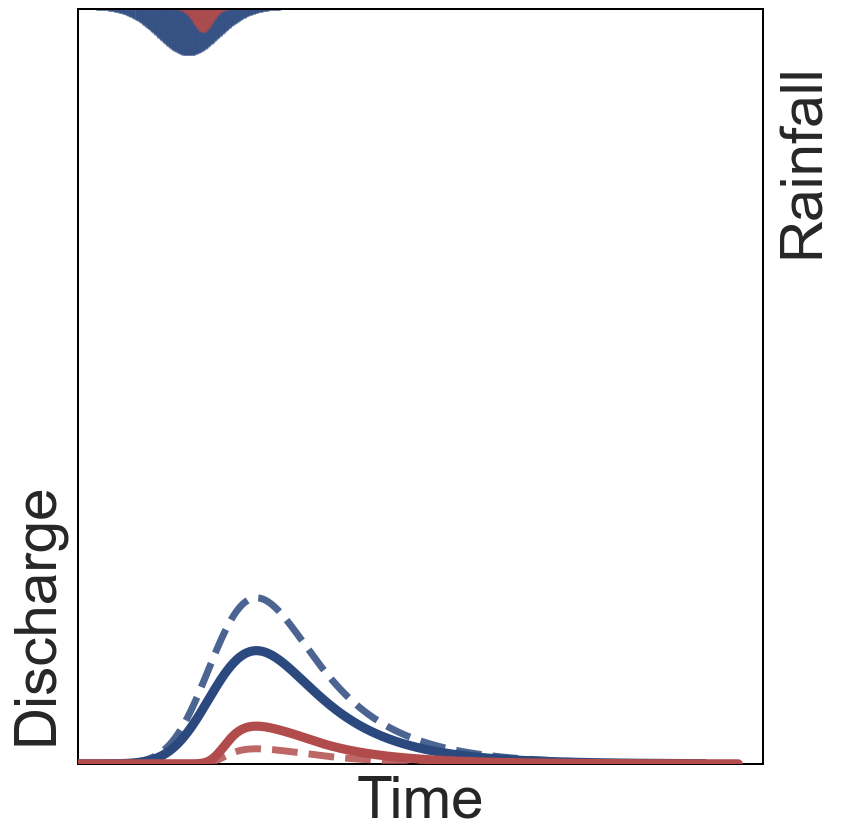

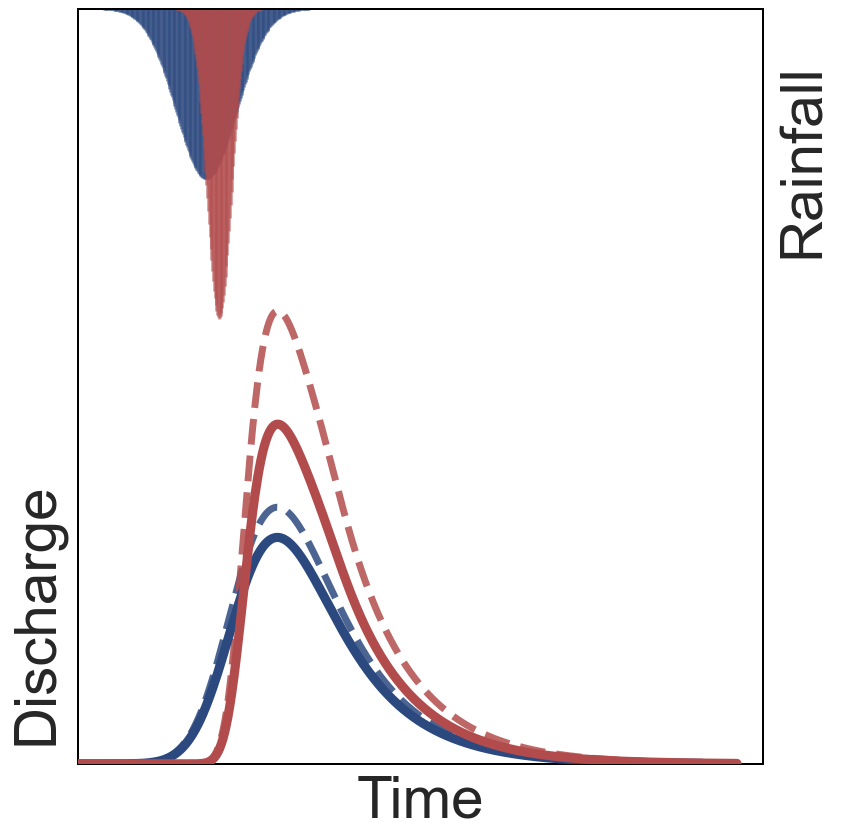

In [13]:
import numpy as np
import matplotlib.pyplot as plt

HIST_COLOR = '#2C497F'   # Historical
FUT_COLOR  = '#B24C4C'   # Future

# =========================
# Global style (bigger text, thicker lines)
# =========================
plt.style.use('seaborn-whitegrid')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.6

plt.rcParams['axes.labelsize'] = 38
plt.rcParams['xtick.labelsize'] = 28
plt.rcParams['ytick.labelsize'] = 28

plt.rcParams['legend.fontsize'] = 24
plt.rcParams['lines.linewidth'] = 4.0


# =========================
# Rain generator (PURE NORMAL, symmetric)
# =========================
def synthetic_rainfall(hours, dt_min, peak_mm_h=25.0, width_h=2.0, peak_time_frac=0.45):
    """Symmetric Gaussian hyetograph (mm/h)."""
    n = int(hours * 60.0 / dt_min)
    t = np.linspace(0, hours, n)
    t0 = hours * peak_time_frac
    sigma = max(0.2, float(width_h))
    r = np.exp(-0.5 * ((t - t0) / (sigma + 1e-9))**2)
    r /= r.max() + 1e-12
    r *= peak_mm_h
    return t, r


# =========================
# Unit hydrograph for discharge (lognormal with fat tail)
# =========================
def lognormal_unit_hydrograph(t, t_mode=1.0, sigma=0.95):
    t = np.asarray(t, dtype=float)
    t_eps = np.maximum(t, 1e-6)
    mu = np.log(t_mode) + sigma**2
    pdf = (1.0 / (t_eps * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(t_eps) - mu)**2 / (2*sigma**2))
    pdf[0] = 0.0
    pdf /= pdf.max() + 1e-12
    return pdf


def _exp_tail_kernel(dt_h, tau_h=6.0, support_h=60.0):
    """
    Exponential tail kernel for post-routing:
    larger tau_h => slower decay (longer recession limb).
    support_h must be long enough so the kernel doesn't truncate the tail.
    """
    tau_h = max(1e-6, float(tau_h))
    n = int(np.ceil(support_h / dt_h))
    tt = np.arange(0, n) * dt_h
    k = np.exp(-tt / tau_h)
    k /= k.sum() + 1e-12
    return k


def runoff_from_rain(t, rain_mm_h, dt_min,
                     uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0,
                     recession_tau_h=7.0, recession_support_h=80.0):
    """
    Convolve rainfall with lognormal UH and delay discharge peak by runoff_delay_h hours.
    Then apply an exponential recession filter to create a longer, slower-decaying tail.

    IMPORTANT: to see Q decay back to ~0, pass a time vector and rainfall series that
    are long enough (rain can be padded with zeros).
    """
    dt_h = dt_min / 60.0
    uh_t = np.arange(0, 10.0, dt_h)
    uh = lognormal_unit_hydrograph(uh_t, t_mode=uh_tmode, sigma=uh_sigma)

    eff = rain_mm_h * dt_h
    q = np.convolve(eff, uh, mode='full')[:len(eff)]
    q /= (dt_h + 1e-12)

    # ---- Add a slower recession limb (tail) ----
    tail_k = _exp_tail_kernel(dt_h, tau_h=recession_tau_h, support_h=recession_support_h)
    q = np.convolve(q, tail_k, mode='full')[:len(q)]

    shift_steps = int(runoff_delay_h / dt_h)
    q = np.roll(q, shift_steps)
    q[:shift_steps] = 0.0
    return q


def normalize_peak(series, desired_peak):
    smax = series.max() if series.max() > 0 else 1.0
    return series * (desired_peak / smax)


# =========================
# Plot helpers (RAIN LOOK UPGRADE)  <-- unchanged
# =========================
def plot_rain_pretty(ax2, t, rain, color, dt_min,
                     gutter=0.18,
                     bar_width_frac=0.28,
                     bar_alpha=0.10,
                     stick_alpha=0.55,
                     stick_lw=2.0):
    """
    Rainfall as thin bars + crisp vertical sticks (hyetograph look).
    Much cleaner than thick bars.
    """
    dt_h = dt_min / 60.0
    rain_vis = rain * (1.0 - gutter)

    bar_width = dt_h * bar_width_frac
    ax2.bar(
        t, rain_vis,
        width=bar_width,
        bottom=0,
        color=color,
        alpha=bar_alpha,
        edgecolor='none',
        align='center',
        zorder=1
    )

    ax2.vlines(
        t, 0, rain_vis,
        colors=color,
        alpha=stick_alpha,
        linewidth=stick_lw,
        zorder=1.15
    )


def make_panel(ax1, ax2, duration_h, dt_min,
               hist_peak_cms, fut_peak_cms,
               hist_rain_peak, hist_width_h, hist_peak_time,
               fut_rain_peak,  fut_width_h,  fut_peak_time,
               uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0,
               recession_tau_h=7.5,
               recession_support_h=60.0,
               tail_plot_h=36.0,  # <<< NEW: how much extra time to show after rainfall duration
               q_ylim=(0, 100), r_ylim=(120, 0),
               t_target_frac=0.55,
               q_lw=6.0,
               dashed_hist_peak=None,
               dashed_fut_peak=None,
               dashed_lw=4.0,
               dashed_ls='--',
               label_fs=40):

    dt_h = dt_min / 60.0

    # --- Rain (original duration) ---
    t_rain, r_hist_short = synthetic_rainfall(duration_h, dt_min, hist_rain_peak, hist_width_h, hist_peak_time)
    _,      r_fut_short  = synthetic_rainfall(duration_h, dt_min, fut_rain_peak,  fut_width_h,  fut_peak_time)

    # --- Extend time for hydrograph tail (pad rainfall with zeros) ---
    extra_steps = int(np.round(tail_plot_h / dt_h))
    n0 = len(t_rain)
    n1 = n0 + extra_steps

    t = np.arange(n1) * dt_h  # extended time vector
    r_hist = np.zeros(n1)
    r_fut  = np.zeros(n1)
    r_hist[:n0] = r_hist_short
    r_fut[:n0]  = r_fut_short

    # --- Discharge (solid) with slower recession ---
    q_hist_raw = runoff_from_rain(
        t, r_hist, dt_min,
        uh_tmode=uh_tmode, uh_sigma=uh_sigma,
        runoff_delay_h=runoff_delay_h,
        recession_tau_h=recession_tau_h,
        recession_support_h=recession_support_h
    )
    q_fut_raw = runoff_from_rain(
        t, r_fut, dt_min,
        uh_tmode=uh_tmode, uh_sigma=uh_sigma,
        runoff_delay_h=runoff_delay_h,
        recession_tau_h=recession_tau_h,
        recession_support_h=recession_support_h
    )

    q_hist = normalize_peak(q_hist_raw, hist_peak_cms)
    q_fut  = normalize_peak(q_fut_raw,  fut_peak_cms)

    # --- Optional dashed hydrographs ---
    q_hist_dashed = None
    q_fut_dashed = None
    if dashed_hist_peak is not None:
        q_hist_dashed = normalize_peak(q_hist_raw, dashed_hist_peak)
    if dashed_fut_peak is not None:
        q_fut_dashed = normalize_peak(q_fut_raw, dashed_fut_peak)

    # Align both to same visual target (use solid peaks as reference)
    t_target = duration_h * t_target_frac
    th = t[np.argmax(q_hist)]
    tf = t[np.argmax(q_fut)]
    dt_hist = t_target - th
    dt_fut  = t_target - tf

    # Draw order
    ax1.set_zorder(2)
    ax2.set_zorder(0)
    ax1.patch.set_alpha(0.0)

    # Rain (behind) - same look; padded zeros won't show
    plot_rain_pretty(ax2, t + dt_hist, r_hist, HIST_COLOR, dt_min)
    plot_rain_pretty(ax2, t + dt_fut,  r_fut,  FUT_COLOR,  dt_min)

    # Solid discharge lines
    ax1.plot(t + dt_hist, q_hist, color=HIST_COLOR, linewidth=q_lw, zorder=3, label='Historical')
    ax1.plot(t + dt_fut,  q_fut,  color=FUT_COLOR,  linewidth=q_lw, zorder=3, label='Future')

    # Dashed discharge lines
    if q_hist_dashed is not None:
        ax1.plot(t + dt_hist, q_hist_dashed,
                 color=HIST_COLOR,
                 linewidth=dashed_lw,
                 linestyle=dashed_ls,
                 alpha=0.85,
                 zorder=2.6)

    if q_fut_dashed is not None:
        ax1.plot(t + dt_fut, q_fut_dashed,
                 color=FUT_COLOR,
                 linewidth=dashed_lw,
                 linestyle=dashed_ls,
                 alpha=0.85,
                 zorder=2.6)

    # Labels / axes
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_yticks([])

    ax1.set_xlabel('Time', fontsize=label_fs, labelpad=8)
    ax1.set_ylabel('Discharge', fontsize=label_fs, labelpad=4)
    ax2.set_ylabel('Rainfall', fontsize=label_fs, labelpad=4)

    ax1.yaxis.set_label_coords(-0.02, 0.20)
    ax2.yaxis.set_label_coords(1.02, 0.80)

    x_end = duration_h + tail_plot_h
    ax1.set_xlim(0, x_end)
    ax1.set_ylim(*q_ylim)
    ax2.set_ylim(*r_ylim)

    # Spines
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.4)
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.4)

    ax1.grid(False)
    ax2.grid(False)


# =========================
# Figure
# =========================
def plot_dual_hydrographs(duration_hours=36, dt_minutes=5):
    # -------- Figure 1: Weak gets weaker --------
    plt.figure(figsize=(8.5, 8.5))
    ax1 = plt.subplot(1, 1, 1)
    ax2 = ax1.twinx()
    make_panel(
        ax1, ax2, duration_hours, dt_minutes,
        hist_peak_cms=15, fut_peak_cms=5,
        hist_rain_peak=6,  hist_width_h=3.4, hist_peak_time=0.52,
        fut_rain_peak=3,   fut_width_h=1.0,  fut_peak_time=0.46,
        runoff_delay_h=1.0,
        recession_tau_h=7.5,
        recession_support_h=80.0,
        tail_plot_h=40.0,          # <<< increase if you still don't reach ~0
        dashed_hist_peak=22,
        dashed_fut_peak=2,
        q_ylim=(0, 100), r_ylim=(80, 0),
        t_target_frac=0.55,
        q_lw=6.6,
        dashed_lw=5.0,
        dashed_ls='--',
        label_fs=42
    )
    plt.tight_layout()
    plt.show()

    # -------- Figure 2: Strong gets stronger --------
    plt.figure(figsize=(8.5, 8.5))
    ax3 = plt.subplot(1, 1, 1)
    ax4 = ax3.twinx()
    make_panel(
        ax3, ax4, duration_hours, dt_minutes,
        hist_peak_cms=30, fut_peak_cms=45,
        hist_rain_peak=22, hist_width_h=3.0, hist_peak_time=0.52,
        fut_rain_peak=40,  fut_width_h=1.2,  fut_peak_time=0.46,
        runoff_delay_h=1.0,
        recession_tau_h=6.5,
        recession_support_h=70.0,
        tail_plot_h=32.0,
        dashed_hist_peak=34,
        dashed_fut_peak=60,
        q_ylim=(0, 100), r_ylim=(80, 0),
        t_target_frac=0.55,
        q_lw=6.6,
        dashed_lw=5.0,
        dashed_ls='--',
        label_fs=42
    )
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_dual_hydrographs()


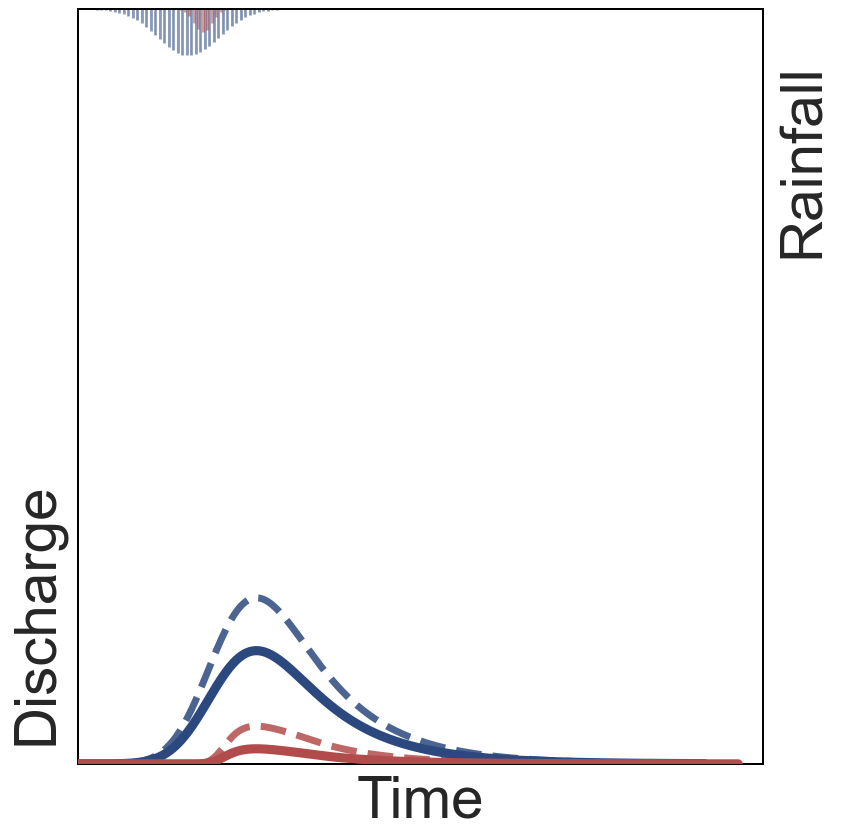

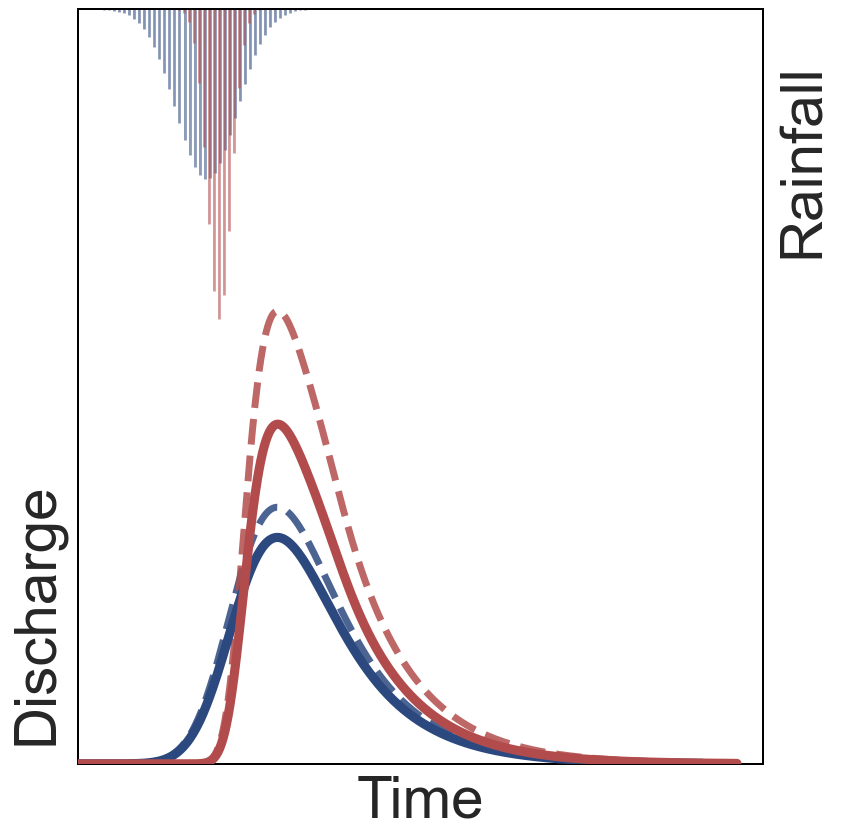

In [15]:
import numpy as np
import matplotlib.pyplot as plt

HIST_COLOR = '#2C497F'   # Historical
FUT_COLOR  = '#B24C4C'   # Future

# =========================
# Global style (bigger text, thicker lines)
# =========================
plt.style.use('seaborn-whitegrid')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.6

plt.rcParams['axes.labelsize'] = 38
plt.rcParams['xtick.labelsize'] = 28
plt.rcParams['ytick.labelsize'] = 28

plt.rcParams['legend.fontsize'] = 24
plt.rcParams['lines.linewidth'] = 4.0


# =========================
# Rain generator (PURE NORMAL, symmetric)
# =========================
def synthetic_rainfall(hours, dt_min, peak_mm_h=25.0, width_h=2.0, peak_time_frac=0.45):
    """Symmetric Gaussian hyetograph (mm/h)."""
    n = int(hours * 60.0 / dt_min)
    t = np.linspace(0, hours, n)
    t0 = hours * peak_time_frac
    sigma = max(0.2, float(width_h))
    r = np.exp(-0.5 * ((t - t0) / (sigma + 1e-9))**2)
    r /= r.max() + 1e-12
    r *= peak_mm_h
    return t, r


# =========================
# Unit hydrograph for discharge (lognormal with fat tail)
# =========================
def lognormal_unit_hydrograph(t, t_mode=1.0, sigma=0.95):
    t = np.asarray(t, dtype=float)
    t_eps = np.maximum(t, 1e-6)
    mu = np.log(t_mode) + sigma**2
    pdf = (1.0 / (t_eps * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(t_eps) - mu)**2 / (2*sigma**2))
    pdf[0] = 0.0
    pdf /= pdf.max() + 1e-12
    return pdf


def _exp_tail_kernel(dt_h, tau_h=6.0, support_h=60.0):
    """
    Exponential tail kernel for post-routing:
    larger tau_h => slower decay (longer recession limb).
    support_h must be long enough so the kernel doesn't truncate the tail.
    """
    tau_h = max(1e-6, float(tau_h))
    n = int(np.ceil(support_h / dt_h))
    tt = np.arange(0, n) * dt_h
    k = np.exp(-tt / tau_h)
    k /= k.sum() + 1e-12
    return k


def runoff_from_rain(t, rain_mm_h, dt_min,
                     uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0,
                     recession_tau_h=7.0, recession_support_h=80.0):
    """
    Convolve rainfall with lognormal UH and delay discharge peak by runoff_delay_h hours.
    Then apply an exponential recession filter to create a longer, slower-decaying tail.
    """
    dt_h = dt_min / 60.0
    uh_t = np.arange(0, 10.0, dt_h)
    uh = lognormal_unit_hydrograph(uh_t, t_mode=uh_tmode, sigma=uh_sigma)

    eff = rain_mm_h * dt_h
    q = np.convolve(eff, uh, mode='full')[:len(eff)]
    q /= (dt_h + 1e-12)

    # Slower recession limb (tail)
    tail_k = _exp_tail_kernel(dt_h, tau_h=recession_tau_h, support_h=recession_support_h)
    q = np.convolve(q, tail_k, mode='full')[:len(q)]

    shift_steps = int(runoff_delay_h / dt_h)
    q = np.roll(q, shift_steps)
    q[:shift_steps] = 0.0
    return q


def normalize_peak(series, desired_peak):
    smax = series.max() if series.max() > 0 else 1.0
    return series * (desired_peak / smax)


# =========================
# Plot helpers (RAIN LOOK)  <-- same look, fewer bars
# =========================
def plot_rain_pretty(ax2, t, rain, color, dt_min,
                     gutter=0.18,
                     bar_width_frac=0.28,
                     bar_alpha=0.10,
                     stick_alpha=0.55,
                     stick_lw=2.0,
                     rain_plot_dt_min=20):
    """
    Rainfall as thin bars + crisp vertical sticks (hyetograph look).

    rain_plot_dt_min controls how many bars you draw (visual only).
    Example: dt_min=5 and rain_plot_dt_min=20 -> draw every 4th bar.
    """
    dt_h = dt_min / 60.0
    rain_vis = rain * (1.0 - gutter)

    step = int(max(1, round(float(rain_plot_dt_min) / float(dt_min))))
    tt = t[::step]
    rr = rain_vis[::step]

    bar_width = (dt_h * step) * bar_width_frac
    ax2.bar(
        tt, rr,
        width=bar_width,
        bottom=0,
        color=color,
        alpha=bar_alpha,
        edgecolor='none',
        align='center',
        zorder=1
    )

    ax2.vlines(
        tt, 0, rr,
        colors=color,
        alpha=stick_alpha,
        linewidth=stick_lw,
        zorder=1.15
    )


def make_panel(ax1, ax2, duration_h, dt_min,
               hist_peak_cms, fut_peak_cms,
               hist_rain_peak, hist_width_h, hist_peak_time,
               fut_rain_peak,  fut_width_h,  fut_peak_time,
               uh_tmode=1.0, uh_sigma=0.95, runoff_delay_h=1.0,
               recession_tau_h=7.5,
               recession_support_h=60.0,
               tail_plot_h=36.0,
               q_ylim=(0, 100), r_ylim=(120, 0),
               t_target_frac=0.55,
               q_lw=6.0,
               dashed_hist_peak=None,
               dashed_fut_peak=None,
               dashed_lw=4.0,
               dashed_ls='--',
               label_fs=40,
               rain_plot_dt_min=20):

    dt_h = dt_min / 60.0

    # Rain (original duration)
    t_rain, r_hist_short = synthetic_rainfall(duration_h, dt_min, hist_rain_peak, hist_width_h, hist_peak_time)
    _,      r_fut_short  = synthetic_rainfall(duration_h, dt_min, fut_rain_peak,  fut_width_h,  fut_peak_time)

    # Extend time for hydrograph tail (pad rainfall with zeros)
    extra_steps = int(np.round(tail_plot_h / dt_h))
    n0 = len(t_rain)
    n1 = n0 + extra_steps

    t = np.arange(n1) * dt_h
    r_hist = np.zeros(n1)
    r_fut  = np.zeros(n1)
    r_hist[:n0] = r_hist_short
    r_fut[:n0]  = r_fut_short

    # Discharge (solid)
    q_hist_raw = runoff_from_rain(
        t, r_hist, dt_min,
        uh_tmode=uh_tmode, uh_sigma=uh_sigma,
        runoff_delay_h=runoff_delay_h,
        recession_tau_h=recession_tau_h,
        recession_support_h=recession_support_h
    )
    q_fut_raw = runoff_from_rain(
        t, r_fut, dt_min,
        uh_tmode=uh_tmode, uh_sigma=uh_sigma,
        runoff_delay_h=runoff_delay_h,
        recession_tau_h=recession_tau_h,
        recession_support_h=recession_support_h
    )

    q_hist = normalize_peak(q_hist_raw, hist_peak_cms)
    q_fut  = normalize_peak(q_fut_raw,  fut_peak_cms)

    # Optional dashed hydrographs
    q_hist_dashed = None
    q_fut_dashed = None
    if dashed_hist_peak is not None:
        q_hist_dashed = normalize_peak(q_hist_raw, dashed_hist_peak)
    if dashed_fut_peak is not None:
        q_fut_dashed = normalize_peak(q_fut_raw, dashed_fut_peak)

    # Align both to same visual target (use solid peaks as reference)
    t_target = duration_h * t_target_frac
    th = t[np.argmax(q_hist)]
    tf = t[np.argmax(q_fut)]
    dt_hist = t_target - th
    dt_fut  = t_target - tf

    # Draw order
    ax1.set_zorder(2)
    ax2.set_zorder(0)
    ax1.patch.set_alpha(0.0)

    # Rain (behind) with fewer bars
    plot_rain_pretty(ax2, t + dt_hist, r_hist, HIST_COLOR, dt_min, rain_plot_dt_min=rain_plot_dt_min)
    plot_rain_pretty(ax2, t + dt_fut,  r_fut,  FUT_COLOR,  dt_min, rain_plot_dt_min=rain_plot_dt_min)

    # Solid discharge lines
    ax1.plot(t + dt_hist, q_hist, color=HIST_COLOR, linewidth=q_lw, zorder=3, label='Historical')
    ax1.plot(t + dt_fut,  q_fut,  color=FUT_COLOR,  linewidth=q_lw, zorder=3, label='Future')

    # Dashed discharge lines
    if q_hist_dashed is not None:
        ax1.plot(t + dt_hist, q_hist_dashed,
                 color=HIST_COLOR,
                 linewidth=dashed_lw,
                 linestyle=dashed_ls,
                 alpha=0.85,
                 zorder=2.6)

    if q_fut_dashed is not None:
        ax1.plot(t + dt_fut, q_fut_dashed,
                 color=FUT_COLOR,
                 linewidth=dashed_lw,
                 linestyle=dashed_ls,
                 alpha=0.85,
                 zorder=2.6)

    # Labels / axes
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_yticks([])

    ax1.set_xlabel('Time', fontsize=label_fs, labelpad=8)
    ax1.set_ylabel('Discharge', fontsize=label_fs, labelpad=4)
    ax2.set_ylabel('Rainfall', fontsize=label_fs, labelpad=4)

    ax1.yaxis.set_label_coords(-0.02, 0.20)
    ax2.yaxis.set_label_coords(1.02, 0.80)

    x_end = duration_h + tail_plot_h
    ax1.set_xlim(0, x_end)
    ax1.set_ylim(*q_ylim)
    ax2.set_ylim(*r_ylim)

    # Spines
    for spine in ax1.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.4)
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.4)

    ax1.grid(False)
    ax2.grid(False)


# =========================
# Figure
# =========================
def plot_dual_hydrographs(duration_hours=36, dt_minutes=5, rain_plot_dt_min=20):
    # Figure 1: Weak gets weaker
    plt.figure(figsize=(8.5, 8.5))
    ax1 = plt.subplot(1, 1, 1)
    ax2 = ax1.twinx()
    make_panel(
        ax1, ax2, duration_hours, dt_minutes,
        hist_peak_cms=15, fut_peak_cms=2,
        hist_rain_peak=6,  hist_width_h=3.4, hist_peak_time=0.52,
        fut_rain_peak=3,   fut_width_h=1.0,  fut_peak_time=0.46,
        runoff_delay_h=1.0,
        recession_tau_h=7.5,
        recession_support_h=80.0,
        tail_plot_h=40.0,
        dashed_hist_peak=22,
        dashed_fut_peak=5,
        q_ylim=(0, 100), r_ylim=(80, 0),
        t_target_frac=0.55,
        q_lw=6.6,
        dashed_lw=5.0,
        dashed_ls='--',
        label_fs=42,
        rain_plot_dt_min=rain_plot_dt_min  # <<< applied to Figure 1
    )
    plt.tight_layout()
    plt.show()

    # Figure 2: Strong gets stronger
    plt.figure(figsize=(8.5, 8.5))
    ax3 = plt.subplot(1, 1, 1)
    ax4 = ax3.twinx()
    make_panel(
        ax3, ax4, duration_hours, dt_minutes,
        hist_peak_cms=30, fut_peak_cms=45,
        hist_rain_peak=22, hist_width_h=3.0, hist_peak_time=0.52,
        fut_rain_peak=40,  fut_width_h=1.2,  fut_peak_time=0.46,
        runoff_delay_h=1.0,
        recession_tau_h=6.5,
        recession_support_h=70.0,
        tail_plot_h=32.0,
        dashed_hist_peak=34,
        dashed_fut_peak=60,
        q_ylim=(0, 100), r_ylim=(80, 0),
        t_target_frac=0.55,
        q_lw=6.6,
        dashed_lw=5.0,
        dashed_ls='--',
        label_fs=42,
        rain_plot_dt_min=rain_plot_dt_min  # <<< applied to Figure 2
    )
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_dual_hydrographs(rain_plot_dt_min=30)
